# Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Importing the dataset

In [2]:
credit_card_data = pd.read_csv('creditcard.csv')

# Data Analysis

In [3]:
# First 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
#dataset Information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
#Check for missing values in each column
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Distribution of legit transactions and fraudulent transactions


In [6]:
# 0 -----> Normal Transaction
# 1 -----> Fraudulent Transaction

credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


This dataset is highly unbalanced

## Separating the data for analysis

In [7]:
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [8]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [9]:
#Statistical measures of the data
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [10]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [11]:
# compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


# Data Preprocessing

## Under-Sampling

### Building a sample dataset containing similar distribution of normal transactions and fraudulent transactions

In [13]:
# Split the original data first so the final test set remains untouched.
X_full = credit_card_data.drop(columns=['Class'])
y_full = credit_card_data['Class']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

# Recombine only the training portion so we can under-sample it.
train_data = pd.concat([X_train_full, y_train_full], axis=1)

legit_train = train_data[train_data['Class'] == 0]
fraud_train = train_data[train_data['Class'] == 1]

# Use less aggressive under-sampling: approximately 4 legitimate transactions
# for every fraud transaction.
legit_sample = legit_train.sample(
    n=min(len(legit_train), 4 * len(fraud_train)),
    random_state=42
)

new_dataset = pd.concat([fraud_train, legit_sample], axis=0)

X = new_dataset.iloc[:, :-1]
y = new_dataset.iloc[:, -1]

print("Original training data:", X_train_full.shape)
print("Original testing data:", X_test.shape)
print("Under-sampled training data:", X.shape)
print("Class distribution:")
print(y.value_counts())

Original training data: (227845, 30)
Original testing data: (56962, 30)
Under-sampled training data: (1970, 30)
Class distribution:
Class
0    1576
1     394
Name: count, dtype: int64


In [14]:
legit_sample.shape

(1576, 31)

### Concatenating two dataframes

In [ ]:
# Under-sampled training data is created above.

In [15]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
42887,41285.0,-12.835760,6.574615,-12.788462,8.786257,-10.723121,-2.813536,-14.248847,7.960521,-7.718751,...,2.679490,-0.047335,-0.836982,0.625349,0.125865,0.177624,-0.817680,-0.521030,37.32,1
6338,7551.0,0.316459,3.809076,-5.615159,6.047445,1.554026,-2.651353,-0.746579,0.055586,-2.678679,...,0.208828,-0.511747,-0.583813,-0.219845,1.474753,0.491192,0.518868,0.402528,1.00,1
88897,62341.0,-5.267760,2.506719,-5.290925,4.886134,-3.343188,-1.100085,-5.810509,1.726343,-0.749277,...,0.764266,0.473262,0.548482,-0.156850,-0.710187,-0.366423,-1.486766,0.677664,1.10,1
74794,55760.0,-6.003422,-3.930731,-0.007045,1.714669,3.414667,-2.329583,-1.901512,-2.746111,0.887673,...,1.101671,-0.992494,-0.698259,0.139898,-0.205151,-0.472412,1.775378,-0.104285,311.91,1
107067,70270.0,-1.512516,1.133139,-1.601052,2.813401,-2.664503,-0.310371,-1.520895,0.852996,-1.496495,...,0.729828,0.485286,0.567005,0.323586,0.040871,0.825814,0.414482,0.267265,318.11,1


In [16]:
new_dataset.shape

(1970, 31)

In [17]:
new_dataset['Class'].value_counts()

,count
Class,
0,1576
1,394


In [18]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95031.787437,-0.046197,0.023405,0.023062,-0.021462,-0.059700,0.007489,0.021795,-0.010335,0.003758,...,-0.013436,0.012201,0.032625,0.01743,-0.000151,-0.003029,-0.005061,-0.000648,-0.000452,93.554099
1,82832.177665,-4.707808,3.588729,-7.068378,4.592975,-3.101629,-1.387192,-5.539909,0.587920,-2.589654,...,0.358018,0.628814,0.051318,-0.06279,-0.109108,0.019602,0.047827,0.155933,0.077212,125.591472


The under-sampling is performed only on the training data, while the test data is kept untouched.

## Splitting the data into features and targets

In [19]:
# X and y for the under-sampled training data are created above.

In [20]:
print(X)
print(y)

            Time         V1        V2         V3        V4         V5  \
42887    41285.0 -12.835760  6.574615 -12.788462  8.786257 -10.723121   
6338      7551.0   0.316459  3.809076  -5.615159  6.047445   1.554026   
88897    62341.0  -5.267760  2.506719  -5.290925  4.886134  -3.343188   
74794    55760.0  -6.003422 -3.930731  -0.007045  1.714669   3.414667   
107067   70270.0  -1.512516  1.133139  -1.601052  2.813401  -2.664503   
...          ...        ...       ...        ...       ...        ...   
21050    31435.0  -7.718141  7.103851  -3.623808 -0.103684  -2.773848   
114273   73408.0   0.987462 -0.394602   0.168199  0.843296  -0.458548   
98533    66698.0   1.087866 -0.451992   0.847824  0.606678  -0.739952   
280835  169783.0  -0.568892  1.203817  -0.296964 -0.781306   0.270540   
118683   75174.0   1.400231 -0.733406   0.265267 -1.002583  -0.556850   

              V6         V7         V8        V9  ...       V20        V21  \
42887  -2.813536 -14.248847   7.960521 -7.718

## Splitting the data into training and testing data

In [21]:
# Keep the original test set untouched.
# Split the training data again to create a validation set for threshold selection.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (1576, 30)
Validation data: (394, 30)
Testing data: (56962, 30)


In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1576, 30)
Testing data: (56962, 30)


# Model Training

## Logistic Regression

In [23]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=7500, random_state=42))
])

## Training the Logistic Regression Model with Training Data


In [24]:
model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=7500, random_state=42))])

## Random Forest Classifier

In [25]:
model2 = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)

In [26]:
model2.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [27]:
# Select a classification threshold using the validation set.
# The test set is not used to choose the threshold.
def find_best_threshold(y_true, probabilities, min_recall=0.80):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_threshold = 0.50
    best_precision = -1

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        recall = metrics.recall_score(y_true, predictions, zero_division=0)
        precision = metrics.precision_score(y_true, predictions, zero_division=0)

        if recall >= min_recall and precision > best_precision:
            best_precision = precision
            best_threshold = threshold

    return best_threshold

X_val_probability1 = model.predict_proba(X_val)[:, 1]
X_val_probability2 = model2.predict_proba(X_val)[:, 1]

threshold1 = find_best_threshold(y_val, X_val_probability1, min_recall=0.80)
threshold2 = find_best_threshold(y_val, X_val_probability2, min_recall=0.80)

print("Logistic Regression threshold:", threshold1)
print("Random Forest threshold:", threshold2)


Logistic Regression threshold: 0.6800000000000002
Random Forest threshold: 0.6700000000000002


# Model Evaluation

In [28]:
def model_stats(y_test, y_pred):
  print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))
  print("Precision: ", metrics.precision_score(y_test, y_pred, zero_division=0))
  print("Recall: ", metrics.recall_score(y_test, y_pred, zero_division=0))
  print("F1 Score: ", metrics.f1_score(y_test, y_pred, zero_division=0))

## Model Statistics for Logistic Regression

In [29]:
# On training data
X_train_prediction1 = model.predict(X_train)

In [30]:
model_stats(y_train, X_train_prediction1)

Accuracy:  0.9758883248730964
Precision:  0.9859649122807017
Recall:  0.8920634920634921
F1 Score:  0.9366666666666666


In [31]:
# On testing data
X_test_probability1 = model.predict_proba(X_test)[:, 1]
X_test_prediction1 = (X_test_probability1 >= threshold1).astype(int)

model_stats(y_test, X_test_prediction1)

Accuracy:  0.9946104420490853
Precision:  0.22715404699738903
Recall:  0.8877551020408163
F1 Score:  0.36174636174636177


In [32]:
model_stats(y_test, X_test_prediction1)

Accuracy:  0.9946104420490853
Precision:  0.22715404699738903
Recall:  0.8877551020408163
F1 Score:  0.36174636174636177


In [33]:
# AUC calculation using probability scores
X_test_probability1 = model.predict_proba(X_test)[:, 1]
auc1 = metrics.roc_auc_score(y_test, X_test_probability1)
print("Logistic Regression ROC-AUC:", auc1)

Logistic Regression ROC-AUC: 0.9721632638705454


## Model Statistics for Random Forest Classifier

In [34]:
# On training data
X_train_prediction2 = model2.predict(X_train)

In [35]:
model_stats(y_train, X_train_prediction2)

Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1 Score:  1.0


In [36]:
# On testing data
X_test_probability2 = model2.predict_proba(X_test)[:, 1]
X_test_prediction2 = (X_test_probability2 >= threshold2).astype(int)

model_stats(y_test, X_test_prediction2)

Accuracy:  0.9988062216916541
Precision:  0.6041666666666666
Recall:  0.8877551020408163
F1 Score:  0.71900826446281


In [37]:
model_stats(y_test, X_test_prediction2)

Accuracy:  0.9988062216916541
Precision:  0.6041666666666666
Recall:  0.8877551020408163
F1 Score:  0.71900826446281


In [38]:
# AUC calculation using probability scores
X_test_probability2 = model2.predict_proba(X_test)[:, 1]
auc2 = metrics.roc_auc_score(y_test, X_test_probability2)
print("Random Forest ROC-AUC:", auc2)

Random Forest ROC-AUC: 0.9784398758800088


In [39]:
# Precision-Recall AUC
pr_auc1 = metrics.average_precision_score(y_test, X_test_probability1)
pr_auc2 = metrics.average_precision_score(y_test, X_test_probability2)

print("Logistic Regression PR-AUC:", pr_auc1)
print("Random Forest PR-AUC:", pr_auc2)


Logistic Regression PR-AUC: 0.7257190599055267
Random Forest PR-AUC: 0.7184008452073682


# Visualization

## Confusion Matrix

## For Logistic Regression

Text(0.5, 427.9555555555555, 'Predicted')

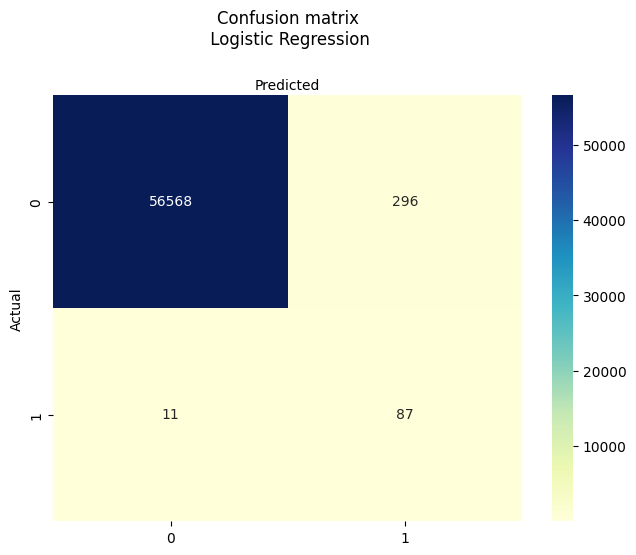

In [40]:
cnf_matrix = metrics.confusion_matrix(y_test, X_test_prediction1)

class_names = [0,1] # Our categories

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g') # Creating heatmap
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix\n Logistic Regression', y = 1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

## For  Random Forest Classifier

Text(0.5, 427.9555555555555, 'Predicted')

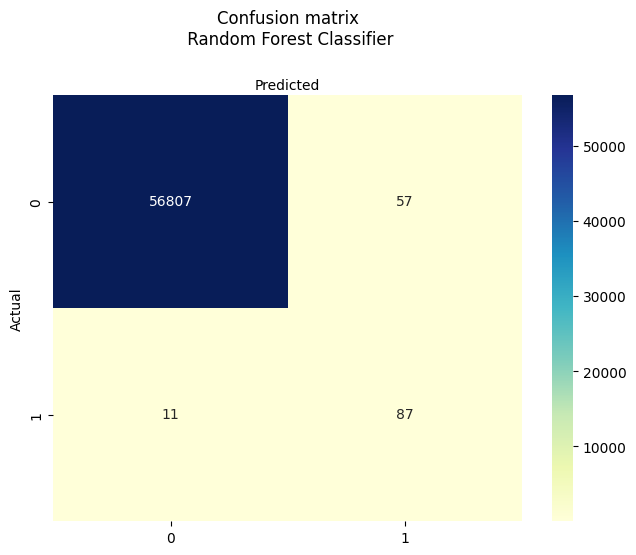

In [41]:
cnf_matrix = metrics.confusion_matrix(y_test, X_test_prediction2)

class_names = [0,1] # Our categories

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g') # Creating heatmap
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix\n Random Forest Classifier', y = 1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

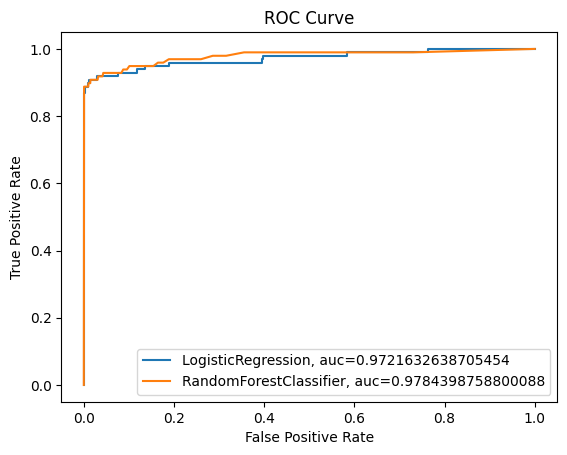

In [42]:
X_test_probability1 = model.predict_proba(X_test)[:, 1]
X_test_probability2 = model2.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = metrics.roc_curve(y_test, X_test_probability1)
fpr2, tpr2, _ = metrics.roc_curve(y_test, X_test_probability2)

plt.plot(fpr1, tpr1, label="LogisticRegression, auc=" + str(auc1))
plt.plot(fpr2, tpr2, label="RandomForestClassifier, auc=" + str(auc2))

plt.legend(loc=4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Conclusion

We can compare the AUC, accuracy, precision and recall of the Random Forest Classifier and Logistic Regression model. Random Forest may provide higher precision and accuracy, while Logistic Regression may provide higher recall. For fraud detection, these metrics should be considered together rather than relying on accuracy alone.

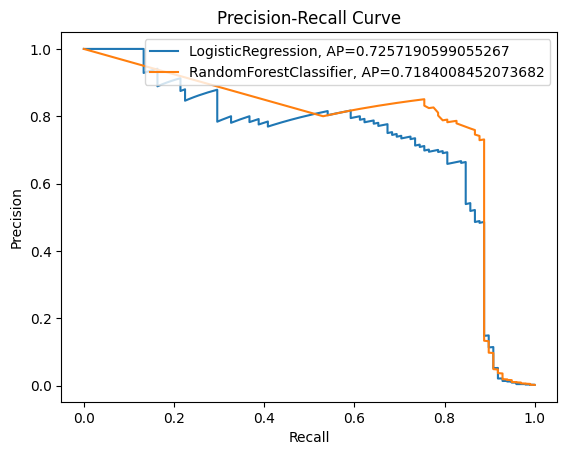

In [43]:
# Precision-Recall Curve
precision1, recall1, _ = metrics.precision_recall_curve(y_test, X_test_probability1)
precision2, recall2, _ = metrics.precision_recall_curve(y_test, X_test_probability2)

plt.plot(recall1, precision1, label="LogisticRegression, AP=" + str(pr_auc1))
plt.plot(recall2, precision2, label="RandomForestClassifier, AP=" + str(pr_auc2))

plt.legend(loc=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
